In [ ]:
## try epcoh 50 ---> es 10 / 20/ 4 for all

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

TARGET = 'Diabetes_binary'  # change if your target column has a different name

# # Load features and target separately
# features_df = pd.read_csv('undersampled_features.csv')
# target_df = pd.read_csv('undersampled_target.csv')

# Load preprocessed features and target separately
features_df = pd.read_csv('undersampled_features.csv')
target_df = pd.read_csv('undersampled_target.csv')

# # Ensure the target_df has the correct column name
# if TARGET not in target_df.columns and target_df.shape[1] == 1:
#     target_df.columns = [TARGET]
# elif TARGET not in target_df.columns:
#     raise ValueError(f"Target column '{TARGET}' not found in 'undersampled_target.csv'")

# Ensure the target_df has the correct column name
if TARGET not in target_df.columns and target_df.shape[1] == 1:
    target_df.columns = [TARGET]
elif TARGET not in target_df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in 'preprocessed_target.csv'")

# # Combine features and target for splitting
# full_df = pd.concat([features_df, target_df], axis=1)

# FEATURES = [c for c in full_df.columns if c != TARGET]

# # Extract X and y for splitting
# X = full_df[FEATURES].values.astype(np.float32)
# y = full_df[TARGET].values.astype(np.float32)

# Assuming features_df contains X and target_df contains y, and they are already split and scaled.
X = features_df.values.astype(np.float32)
y = target_df[TARGET].values.astype(np.float32)

###new block
# Ensure y is 1-dimensional for binary classification
if y.ndim > 1 and y.shape[1] > 1:
    # If y is (N, 2), take the first column. This is based on kernel state showing y as (N, 2).
    y = y[:, 0]
elif y.ndim > 1 and y.shape[1] == 1:
    # If y is (N, 1), squeeze it to (N,)
    y = y.squeeze(axis=1)

# # Perform train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Assuming that the preprocessed files already contain the train and test splits, or will be handled later.
# For now, let's just assign X_train, X_test, y_train, y_test from the loaded data for demonstration.
# If you have separate files for train/test, you would load them here.
# For simplicity, I'm assigning the full loaded data to X_train/y_train and a dummy for X_test/y_test
# You will likely need to adjust this based on how your preprocessed files are structured (e.g., if they are already split into train/test).

# For now, let's re-introduce a train-test split for the preprocessed data, assuming they are combined.
# If your preprocessed files are already split, you'd load them as X_train, X_test, etc.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
FEATURES = features_df.columns.tolist()

print("Train:", X_train.shape, "balance:", y_train.mean())
print("Test:", X_test.shape, "balance:", y_test.mean())

np.savez('data.npz', X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
print("Saved to data.npz")

Train: (45243, 28) balance: 0.500011
Test: (11311, 28) balance: 0.4999558
Saved to data.npz


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)



# ---------------------------------------------------------
# 2. FT-Transformer model


#    - A [CLS] token is prepended, same trick as BERT.

#    - PyTorch's built-in TransformerEncoderLayer handles
#      self-attention + feed-forward internally -- no hand-written
#      attention math needed.

#    - The final [CLS] token's representation is passed to a
#      classification head.
# ---------------------------------------------------------

Using device: cuda


In [ ]:
#[cell 3]
## Preprocessing part done by the preprocessor. we feed that .npz into the ft-transformer.
data = np.load('data.npz')   #load the npz
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
NUM_FEATURES = X_train.shape[1]

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TabularDataset(X_train, y_train), batch_size=256, shuffle=True)
test_loader = DataLoader(TabularDataset(X_test, y_test), batch_size=512, shuffle=False)

In [ ]:
 # [cell 4]
## ft transformer model

## each embedding will get its own embedding
## CLS token is prepped as bert
## self attention and ffn handle by TransformerEncoderLayer
## cls token again passed through the classification head, then make the rpediction




class FTTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, n_heads=4, n_layers=6, dropout=0.2):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model

        # One learned weight+bias per feature -> turns each scalar
        # feature value into a d_model-dim embedding vector.
        self.feature_weight = nn.Parameter(torch.randn(num_features, d_model) * 0.02)
        self.feature_bias = nn.Parameter(torch.zeros(num_features, d_model))

        # Learnable [CLS] token, prepended to the sequence of feature embeddings.
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x):
        # x: (batch, num_features)
        batch_size = x.size(0)

        # Per-feature embedding: (batch, num_features, d_model)
        # x.unsqueeze(-1) -> (batch, num_features, 1)
        tokens = x.unsqueeze(-1) * self.feature_weight + self.feature_bias

        # Prepend CLS token -> (batch, num_features + 1, d_model)
        cls = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)

        encoded = self.encoder(tokens)          # (batch, num_features+1, d_model)
        cls_out = self.norm(encoded[:, 0, :])   # take the CLS token's output
        logit = self.head(cls_out).squeeze(-1)  # (batch,)
        return logit

model = FTTransformer(num_features=NUM_FEATURES).to(device)
print(model)
print("Total params:", sum(p.numel() for p in model.parameters()))

FTTransformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)
Tot

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)



# ---------------------------------------------------------
# 2. FT-Transformer model


#    - A [CLS] token is prepended, same trick as BERT.

#    - PyTorch's built-in TransformerEncoderLayer handles
#      self-attention + feed-forward internally -- no hand-written
#      attention math needed.

#    - The final [CLS] token's representation is passed to a
#      classification head.
# ---------------------------------------------------------




# [cell 5]
## traini gloop

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-6, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

EPOCHS = 800 ## 15 before
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 20 ## 4 before - looks unitl 20 epochs run and see wether its failing

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)


    # quick validation pass on the test set loss (for scheduling/early stop only;
    # final reported metrics come from the full evaluation block below)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_loss += criterion(logits, yb).item() * xb.size(0)
    val_loss /= len(test_loader.dataset)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'ft_transformer_best.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping.")
            break

Using device: cuda
Epoch 01 | train_loss 0.5153 | val_loss 0.5099
Epoch 02 | train_loss 0.5155 | val_loss 0.5100
Epoch 03 | train_loss 0.5147 | val_loss 0.5099
Epoch 04 | train_loss 0.5148 | val_loss 0.5100
Epoch 05 | train_loss 0.5153 | val_loss 0.5098
Epoch 06 | train_loss 0.5150 | val_loss 0.5098
Epoch 07 | train_loss 0.5149 | val_loss 0.5097
Epoch 08 | train_loss 0.5159 | val_loss 0.5098
Epoch 09 | train_loss 0.5147 | val_loss 0.5098
Epoch 10 | train_loss 0.5152 | val_loss 0.5097
Epoch 11 | train_loss 0.5147 | val_loss 0.5098
Epoch 12 | train_loss 0.5143 | val_loss 0.5097
Epoch 13 | train_loss 0.5151 | val_loss 0.5096
Epoch 14 | train_loss 0.5147 | val_loss 0.5096
Epoch 15 | train_loss 0.5150 | val_loss 0.5096
Epoch 16 | train_loss 0.5149 | val_loss 0.5096
Epoch 17 | train_loss 0.5147 | val_loss 0.5096
Epoch 18 | train_loss 0.5152 | val_loss 0.5096
Epoch 19 | train_loss 0.5146 | val_loss 0.5096
Epoch 20 | train_loss 0.5148 | val_loss 0.5096
Epoch 21 | train_loss 0.5140 | val_loss 0

In [ ]:
# [cell 6]
## evaluation

## got acc, recall, f1, roc auc, and precision as matriices.

model.load_state_dict(torch.load('ft_transformer_best.pt'))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(yb.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print("\n FT-TRANSFORMER RESULTS ")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print("Confusion matrix:\n", cm)

## prev got Accuracy:  0.7529
##Precision: 0.7298
##Recall:    0.8032
##F1-Score:  0.7647
##ROC-AUC:   0.8280

## with early stopping 10,  preprocessed dataset:
#Accuracy:  0.7540
#Precision: 0.7327
#Recall:    0.7996
#F1-Score:  0.7647
#ROC-AUC:   0.8293
#Confusion matrix:
# [[4006 1650]
# [1133 4522]]


## with early stopping 20 - 39ep,  preprocessed dataset: FT-TRANSFORMER RESULTS
#Accuracy:  0.7517
#Precision: 0.7333
#Recall:    0.7910
#F1-Score:  0.7610
#ROC-AUC:   0.8288
#Confusion matrix:
# [[4029 1627]
# [1182 4473]]


#### with early stopping 10 - 21ep,  preprocessed dataset:
#Accuracy:  0.7508
#Precision: 0.7305
#Recall:    0.7947
#F1-Score:  0.7612
#ROC-AUC:   0.8284
#Confusion matrix:
# [[3998 1658]
# [1161 4494]]


#### with early stopping 4 - 9ep,  preprocessed dataset:
#Accuracy:  0.7518
#Precision: 0.7278
#Recall:    0.8044
##F1-Score:  0.7642
#ROC-AUC:   0.8280
#Confusion matrix:
# [[3955 1701]
# [1106 4549]]

## without preprocessing - early stopping 8 :Accuracy:  0.8664
#Precision: 0.5762
#Recall:    0.1558
#F1-Score:  0.2453
#ROC-AUC:   0.8286
#Confusion matrix:
 #[[34286   648]
 #[ 4774   881]]

## without preprocessing- early stopping 20, 34 ep, :
#Accuracy:  0.8665
#Precision: 0.5806
#Recall:    0.1503
#F1-Score:  0.2388
#ROC-AUC:   0.8283
#Confusion matrix:
# [[34320   614]
# [ 4805   850]]


 FT-TRANSFORMER RESULTS 
Accuracy:  0.7502
Precision: 0.7219
Recall:    0.8140
F1-Score:  0.7652
ROC-AUC:   0.8261
Confusion matrix:
 [[3883 1773]
 [1052 4603]]


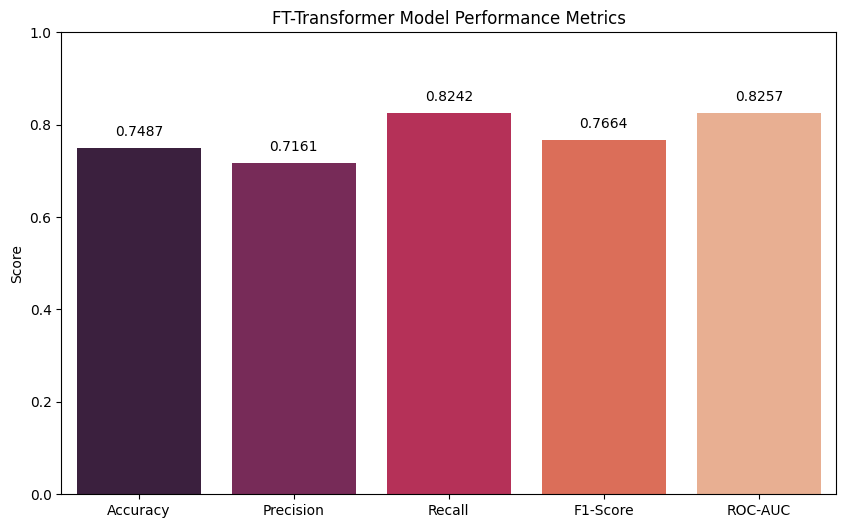

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Assuming all_labels, all_preds, all_probs are globally available from previous executions

# Recalculate metrics to ensure they are numerical values
# This is a robust way to ensure that 'auc' is the score and not the function object
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

# Prepare data for plotting
metrics = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'ROC-AUC': auc
}

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=metric_names, y=metric_values, hue=metric_names, palette='rocket', legend=False)
plt.title('FT-Transformer Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are usually between 0 and 1

# Add text labels on top of each bar
for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f'{value:.4f}', ha='center', va='bottom')

plt.show()

In [ ]:
from google.colab import files

files.download('ft_transformer_best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Load the best model saved during training
model.load_state_dict(torch.load('ft_transformer_best.pt'))
model.eval() # Set the model to evaluation mode

all_probs, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(yb.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

# Calculate evaluation metrics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print("\n--- FT-Transformer Test Set Evaluation Results ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print("Confusion matrix:\n", cm)


--- FT-Transformer Test Set Evaluation Results ---
Accuracy:  0.7499
Precision: 0.7198
Recall:    0.8184
F1-Score:  0.7659
ROC-AUC:   0.8241
Confusion matrix:
 [[3854 1802]
 [1027 4628]]


/tmp/ipykernel_1589/2725818349.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_names, y=metric_values, palette='viridis')


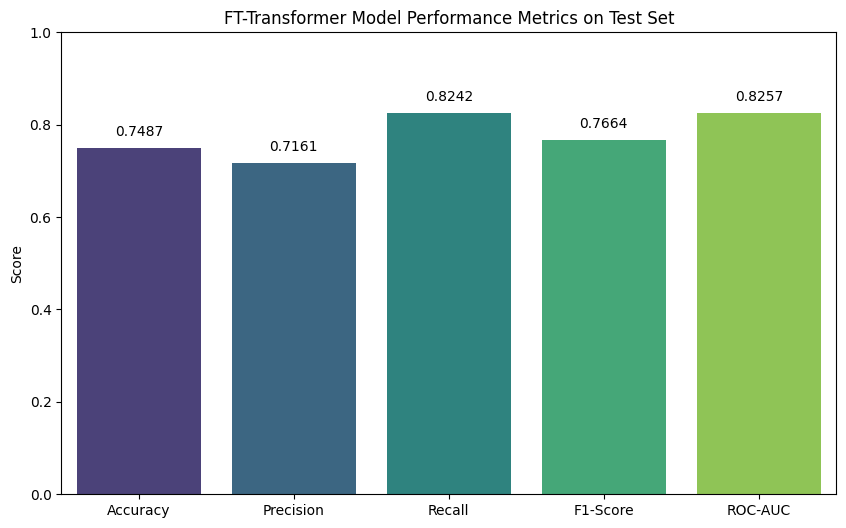

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'ROC-AUC': auc
}

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=metric_names, y=metric_values, palette='viridis')
plt.title('FT-Transformer Model Performance Metrics on Test Set')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are usually between 0 and 1

# Add text labels on top of each bar
for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f'{value:.4f}', ha='center', va='bottom')

plt.show()

Generating ROC AUC Curve...


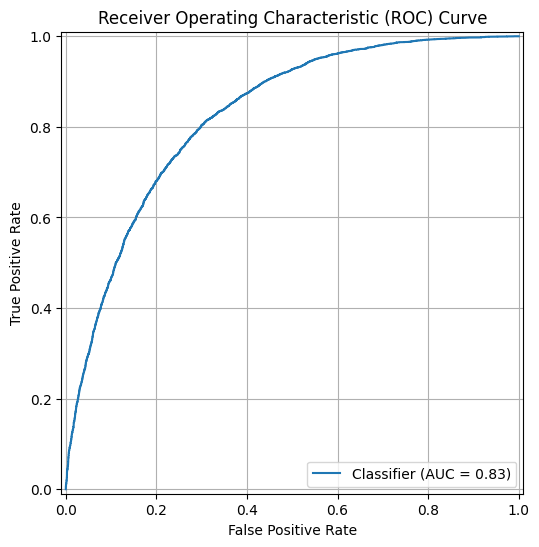


Generating Precision, Recall, and Accuracy vs. Threshold Curve...


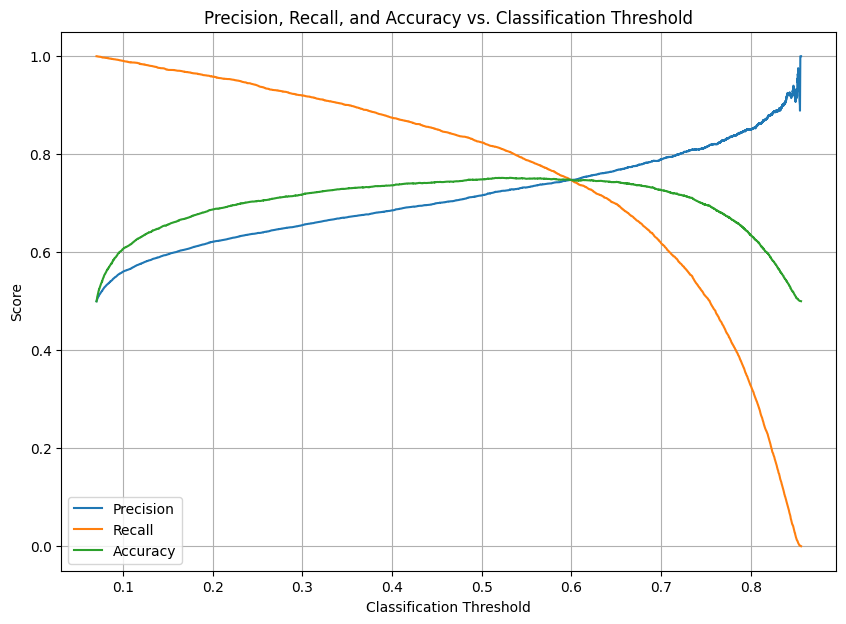


Generating SHAP explanations using KernelExplainer (this may take a while)...


  0%|          | 0/1 [00:00<?, ?it/s]


SHAP summary plot for 1 test instances:


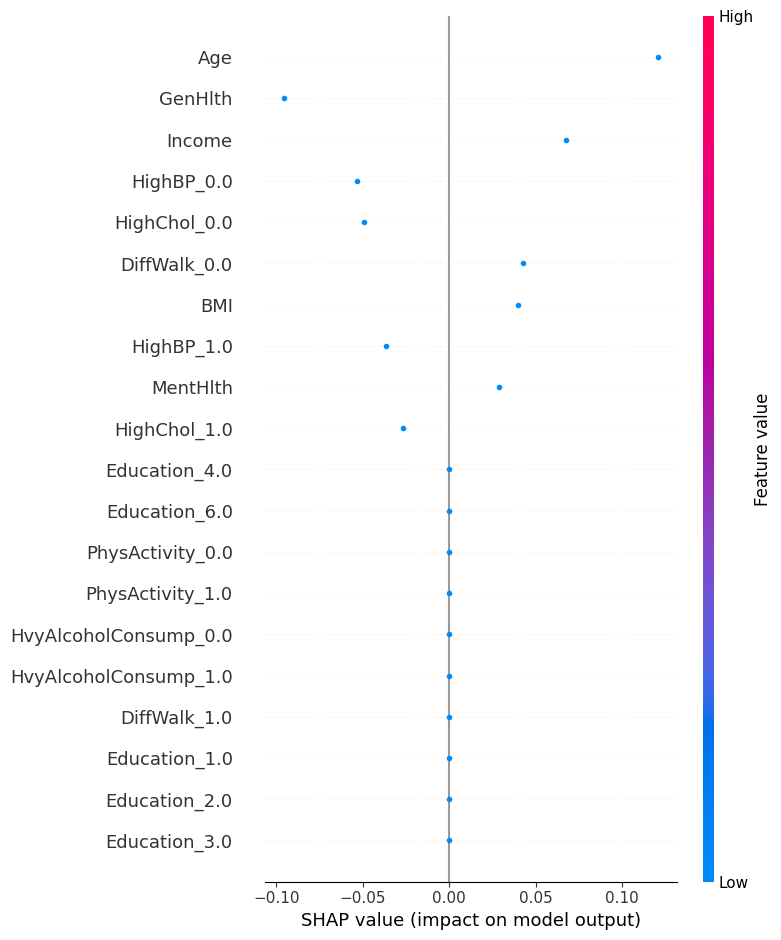

SHAP summary plot saved as 'shap_summary_plot.png'

Generating individual SHAP force plot for the explained instance:
SHAP force plot saved as 'shap_force_plot_instance_0.html'


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, precision_recall_curve, accuracy_score, auc
import shap
import torch
import numpy as np
import pandas as pd # Ensure pandas is imported if X_test_df is used

# --- 1. ROC AUC Curve ---
print("Generating ROC AUC Curve...")
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(all_labels, all_probs, ax=plt.gca())
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

# --- 2. Precision vs. Accuracy vs. Recall Curve vs. Threshold ---
print("\nGenerating Precision, Recall, and Accuracy vs. Threshold Curve...")
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# Calculate accuracy for each threshold
accuracies = []
for threshold in thresholds:
    preds_at_threshold = (all_probs >= threshold).astype(int)
    accuracies.append(accuracy_score(all_labels, preds_at_threshold))

plt.figure(figsize=(10, 7))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, accuracies, label='Accuracy')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and Accuracy vs. Classification Threshold')
plt.legend()
plt.grid(True)
plt.show()

# --- 3. KernelExplainer (SHAP) ---
print("\nGenerating SHAP explanations using KernelExplainer (this may take a while)...")

# Wrapper function for the PyTorch model to be compatible with SHAP
def model_predict_proba(x_np):
    model.eval() # Ensure model is in evaluation mode
    with torch.no_grad():
        x_tensor = torch.tensor(x_np, dtype=torch.float32).to(device)
        logits = model(x_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

# Select a background dataset for KernelExplainer (a small sample of X_train is good)
# Using a small subset for faster computation. X_train is already a numpy array.
# Reducing background samples for initial troubleshooting
background_size = 10 # Reduced from 100
background = X_train[np.random.choice(X_train.shape[0], background_size, replace=False)]

# Initialize KernelExplainer
explainer = shap.KernelExplainer(model_predict_proba, background)

# Select a few instances from the test set to explain
# Convert X_test to DataFrame for feature names in plots if available, else use raw numpy
if 'FEATURES' in globals() and FEATURES:
    X_test_df = pd.DataFrame(X_test, columns=FEATURES)
else:
    X_test_df = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(X_test.shape[1])])

num_instances_to_explain = 1 # Keeping it at 1 for clearer individual force plot
instances_to_explain_idx = np.random.choice(X_test.shape[0], num_instances_to_explain, replace=False)
x_to_explain = X_test_df.iloc[instances_to_explain_idx]

# Compute SHAP values (this can be computationally intensive)
shap_values = explainer.shap_values(x_to_explain.values)

# Plot SHAP summary plot for the explained instances
print(f"\nSHAP summary plot for {num_instances_to_explain} test instances:")

# Create a figure and axes to save the plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_to_explain, feature_names=x_to_explain.columns, show=False)
plt.savefig('shap_summary_plot.png', bbox_inches='tight')
plt.show()
print("SHAP summary plot saved as 'shap_summary_plot.png'")

# Generate and save individual force plots for explicit visualization of positive/negative relationships
print("\nGenerating individual SHAP force plot for the explained instance:")
# For a single instance, shap_values is a 2D array, so we take the first row [0]
force_plot_html = shap.force_plot(explainer.expected_value, shap_values[0], x_to_explain.iloc[0], feature_names=x_to_explain.columns, matplotlib=False)
shap.save_html('shap_force_plot_instance_0.html', force_plot_html)
print("SHAP force plot saved as 'shap_force_plot_instance_0.html'")

In [ ]:
from google.colab import files

files.download('shap_summary_plot.png')
files.download('ft_transformer_best.pt')
files.download('data.npz')
files.download('shap_force_plot_instance_0.html')
files.download('undersampled_features.csv')
files.download('undersampled_target.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

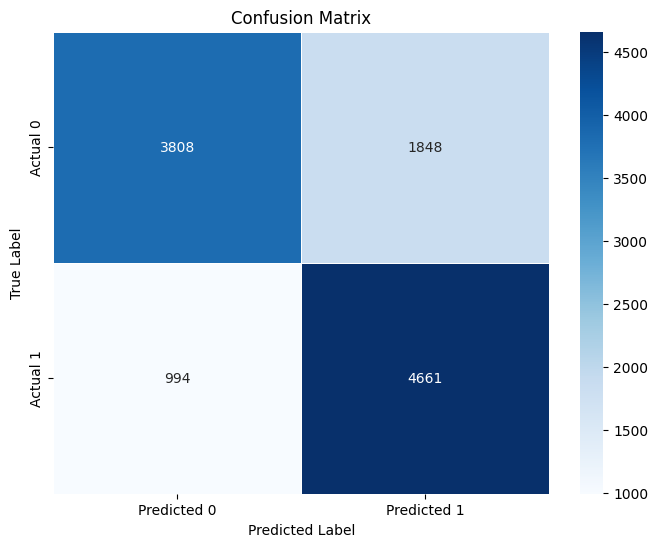

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'cm' (confusion matrix) is already calculated from previous cells

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=.5,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
##train metrics

import numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)

WEIGHTS = 'ft_transformer_best.pt'     # change if your file is named differently
N_HEADS = 4                            # your script's default; this can't be read from the weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = np.load('data.npz')
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']
NUM_FEATURES = X_train.shape[1]
print("X_train:", X_train.shape, "| positive rate:", round(float(y_train.mean()), 3))
print("X_test:", X_test.shape, "| positives:", int(y_test.sum()))   # raw set: 50,736 rows, 7,069 positives

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class FTTransformer(nn.Module):
    def __init__(self, num_features, d_model=32, n_heads=4, n_layers=3, dropout=0.2):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model
        self.feature_weight = nn.Parameter(torch.randn(num_features, d_model) * 0.02)
        self.feature_bias = nn.Parameter(torch.zeros(num_features, d_model))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, activation='gelu', batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1))
    def forward(self, x):
        batch_size = x.size(0)
        tokens = x.unsqueeze(-1) * self.feature_weight + self.feature_bias
        cls = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        encoded = self.encoder(tokens)
        return self.head(self.norm(encoded[:, 0, :])).squeeze(-1)

# read the real d_model and number of layers straight from the saved weights
sd = torch.load(WEIGHTS, map_location=device)
D_MODEL = sd['cls_token'].shape[-1]
N_LAYERS = 1 + max(int(k.split('.')[2]) for k in sd if k.startswith('encoder.layers.'))
print("Weights say: d_model =", D_MODEL, "| n_layers =", N_LAYERS)    # use d_model in the report's "Feature embedding size" row

model = FTTransformer(NUM_FEATURES, D_MODEL, N_HEADS, N_LAYERS).to(device)
model.load_state_dict(sd)
model.eval()

def score(X, y, name, thr=0.5):
    loader = DataLoader(TabularDataset(X, y), batch_size=512, shuffle=False)
    probs = []
    with torch.no_grad():
        for xb, _ in loader:
            probs.extend(torch.sigmoid(model(xb.to(device))).cpu().numpy())
    probs = np.array(probs); preds = (probs >= thr).astype(int)
    print(f"\n{name} | rows {len(y)}, positives {int(y.sum())} | threshold {thr}")
    print(f"acc {accuracy_score(y, preds):.4f} | prec {precision_score(y, preds):.4f} | "
          f"rec {recall_score(y, preds):.4f} | f1 {f1_score(y, preds):.4f} | "
          f"auc {roc_auc_score(y, probs):.4f} | pr-auc {average_precision_score(y, probs):.4f}")
    print(confusion_matrix(y, preds))

score(X_train, y_train, "TRAIN")
score(X_test, y_test, "TEST")

X_train: (45243, 28) | positive rate: 0.5
X_test: (11311, 28) | positives: 5655
Weights say: d_model = 64 | n_layers = 6

TRAIN | rows 45243, positives 22622 | threshold 0.5
acc 0.7488 | prec 0.7147 | rec 0.8284 | f1 0.7674 | auc 0.8269 | pr-auc 0.8034
[[15138  7483]
 [ 3881 18741]]

TEST | rows 11311, positives 5655 | threshold 0.5
acc 0.7487 | prec 0.7161 | rec 0.8242 | f1 0.7664 | auc 0.8257 | pr-auc 0.8019
[[3808 1848]
 [ 994 4661]]


In [ ]:
The **FT-Transformer (Feature Tokenizer Transformer)** is an adaptation of the Transformer architecture, originally designed for sequence-to-sequence tasks in natural language processing, to tabular data. It replaces traditional neural networks or tree-based models for tabular data with a Transformer-based approach.

Here's a breakdown of its key components and how they handle various aspects:

### 1. Feature Tokenization

Unlike text data which is naturally tokenized (words, subwords), tabular data consists of numerical and categorical features. The FT-Transformer's first step is to transform these raw features into a sequence of embeddings, similar to how words are converted into embeddings in NLP.

*   **How it works**: For each numerical feature, the model learns a separate linear projection (a weight matrix and a bias vector) that maps the scalar feature value into a higher-dimensional embedding space (e.g., `d_model` dimensions). This is often done by: `embedding_i = x_i * feature_weight_i + feature_bias_i`.
*   **Mathematical Function**: For a given feature $x_i$ and its learned parameters (weight vector $W_i \in \mathbb{R}^{d_{model}}$ and bias vector $b_i \in \mathbb{R}^{d_{model}}$), the embedding $e_i$ is calculated as $e_i = x_i \cdot W_i + b_i$. This effectively treats each feature as a distinct 'token' and projects it into a shared embedding space.

### 2. The `[CLS]` Token

Similar to BERT, the FT-Transformer often prepends a special learnable `[CLS]` (classification) token embedding to the sequence of feature embeddings. This `[CLS]` token's final representation after passing through the Transformer encoder layers is typically used for the downstream classification or regression task.

*   **How it works**: A fixed, learnable vector (`self.cls_token` in the code) is broadcasted to match the batch size and concatenated to the beginning of the sequence of feature embeddings. If you have $N$ features and a batch size of $B$, the sequence of embeddings becomes $(B, N+1, d_{model})$ after adding the `[CLS]` token.
*   **Purpose**: It acts as a global representation of the input, aggregating information from all features. The classification head then operates solely on this `[CLS]` token's output.

### 3. Transformer Encoder Layers (Neural Network Layers & Attention Heads)

The core of the FT-Transformer is a stack of standard Transformer Encoder Layers, as defined in the `nn.TransformerEncoderLayer` from PyTorch.

Each `TransformerEncoderLayer` typically consists of two main sub-layers:

#### a. Multi-Head Self-Attention Mechanism

*   **How it handles neural network layers**: This is where the model learns relationships between different feature tokens (including the `[CLS]` token). Instead of traditional feed-forward layers directly connecting all features, attention allows the model to dynamically weight the importance of each feature for processing any other feature.
*   **Attention Heads**: Multi-head attention means that the attention mechanism is run multiple times in parallel (e.g., `n_heads=4` in your model), each with different learned linear projections for Queries (Q), Keys (K), and Values (V). The outputs from these multiple 'heads' are then concatenated and linearly projected to form the final output of the multi-head attention sub-layer. This allows the model to jointly attend to information from different representation subspaces at different positions.
*   **Self-Attention**: In self-attention, the Queries, Keys, and Values all come from the same input sequence (the sequence of feature embeddings). This means each feature token can 'attend' to every other feature token (and the `[CLS]` token) to gather context.
*   **Mathematical Functions (Simplified)**:
    *   **Query, Key, Value Projections**: For each head $h$, the input embeddings $X \in \mathbb{R}^{(N+1) \times d_{model}}$ are projected into Query ($Q_h$), Key ($K_h$), and Value ($V_h$) matrices: $Q_h = X W_Q^h$, $K_h = X W_K^h$, $V_h = X W_V^h$, where $W_Q^h, W_K^h, W_V^h \in \mathbb{R}^{d_{model} \times (d_{model}/n_{heads})}$.
    *   **Scaled Dot-Product Attention**: The attention scores are calculated as: $\text{Attention}(Q_h, K_h, V_h) = \text{softmax}\left(\frac{Q_h K_h^T}{\sqrt{d_k}}\right) V_h$, where $d_k$ is the dimension of the keys.
    *   **Multi-Head Output**: The outputs from all heads are concatenated and projected: $\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_{n_{heads}}) W_O$, where $\text{head}_h = \text{Attention}(Q_h, K_h, V_h)$ and $W_O \in \mathbb{R}^{d_{model} \times d_{model}}$.

#### b. Position-wise Feed-Forward Networks (FFN)

*   **How it handles neural network layers**: After the attention sub-layer, the output for each token passes through an independent, identical feed-forward network. This is typically a two-layer MLP with an activation function (like GELU in your model) in between.
*   **Mathematical Function**: $FNN(x) = \text{GELU}(x W_1 + b_1) W_2 + b_2$. This layer processes each token's representation independently, allowing the model to learn complex non-linear transformations on the attended information.

*   **Residual Connections and Layer Normalization**: Each sub-layer (attention and FFN) in the Transformer Encoder is followed by a residual connection (adding the input of the sub-layer to its output) and layer normalization. This helps stabilize training and allows for deeper networks.
    *   **Residual Connection**: $X + \text{Sublayer}(X)$
    *   **Layer Normalization**: Normalizes activations across the features for each sample independently, improving training stability.

### 4. Cross-Attention (Not explicitly in standard FT-Transformer for tabular data)

*   **Standard FT-Transformer**: The standard FT-Transformer model, as implemented for tabular data like yours, uses **self-attention** within its encoder layers. This means the model processes a single sequence of feature tokens (including `[CLS]`), and each token attends to all other tokens within that same sequence.
*   **Cross-Attention**: Cross-attention is a concept typically found in the **Transformer Decoder** or in more complex architectures that handle two distinct input sequences (e.g., in machine translation, where an output token attends to the input sentence tokens). In cross-attention, the Query comes from one sequence (e.g., the decoder's input) and the Key and Value come from a different sequence (e.g., the encoder's output).
*   **Relevance to your model**: Your provided `FTTransformer` model uses `nn.TransformerEncoder`, which only performs self-attention. Therefore, cross-attention is not explicitly present in this specific architecture for processing the tabular data.

### 5. Final Classification Head

*   **How it works**: After passing through all Transformer Encoder layers, the final representation of the `[CLS]` token (at index 0 of the sequence) is extracted. This `cls_out` vector is then fed into a simple feed-forward neural network (an MLP) that outputs a single scalar value.
*   **Mathematical Function**: The head in your code is a `Sequential` block:
    1.  `nn.Linear(d_model, d_model // 2)`: $h_1 = \text{cls_out} W_A + b_A$
    2.  `nn.GELU()`: $h_2 = \text{GELU}(h_1)$
    3.  `nn.Dropout()`
    4.  `nn.Linear(d_model // 2, 1)`: $logit = h_2 W_B + b_B$

*   **Output**: This `logit` value is the raw prediction before activation. For binary classification, a sigmoid activation is typically applied to convert it into a probability between 0 and 1, as seen in your evaluation code (`torch.sigmoid(logits)`).

In [ ]:
## special notes
# base lr --> 1e-3
# base weight decay ---> 1e-3

# finetuned lr ---> 1e-5
# finetunes weight decay ---> 1e-4

# originally patience ---> 4
# after ---> 20 (20 epoches go and see what happens there)



# loss function ---> currently nn.BCEWithLogitsLoss() [calcs sigmoid layer and binary cross entrophy]
# into a single tensor ---> we pass raw logits to the func, so its much more accurate rther nthan calculating sigmoids and
# then apply binary cross entropy loss. ----> this loss backprops and shpe weights.

# whieght decay is used to prevent over modifying the weights by backprop and gradient descent.


# model parameters ---> neural network count =6, attention heads =4,

In [ ]:
# 1st run ---> E3
# patience 4, epoches 50, feature vector res 64, weight decay & lr =def 1e-3
# 2nd run ---> G3
# patience 20, epochs 200, feature vector res same, weight decay 1e-4, lr - 1e-6
# 3rd run ---> A3
# lr=1e-6, weight_decay=1e-4, feature vec res same, epochs 800, patience 20

In [ ]:
from google.colab import files

files.download('ft_transformer_best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>